In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import xarray as xr
import matplotlib.gridspec as gs

%matplotlib inline
%config InlineBackend.figure_format = 'retina'


In [2]:
plt.rcParams.update({
    "text.usetex": False,
    "text.latex.preamble":r'\usepackage{sansmathfonts}\usepackage{helvet}\usepackage{amsmath}\usepackage{amssymb}\usepackage{nicefrac}', 
    "axes.linewidth":2, 
    "axes.titlepad":15, 
    "axes.labelpad":8,
    "axes.labelsize":16.5,
    "axes.titlesize":17.5,
    "xtick.major.width":2, 
    "xtick.minor.width":2, 
    "xtick.major.size":7, 
    "xtick.minor.size":5,
    "ytick.major.width":2, 
    "ytick.minor.width":2, 
    "ytick.major.size":7, 
    "ytick.minor.size":5,
    "ytick.right":True, 
    "xtick.top":True,
    "xtick.major.pad":7,
    "xtick.minor.pad":7,
    "ytick.major.pad":5,
    "ytick.minor.pad":5,
    "xtick.labelsize":18, 
    "ytick.labelsize":18,
    "xtick.direction":'in',
    "ytick.direction":'in',
    "axes.grid":True,
    "grid.alpha":0.5,
    "grid.color":'gray',
    "grid.linestyle":':',
    "grid.linewidth":1.5,
    "lines.linewidth":3,
    "legend.fontsize":12.5,
    "contour.negative_linestyle":'dashed'
    })


In [3]:
ds = xr.open_dataset('/data/ntl203/data_for_ben/phi_avgs_timavg_Raf9.5e8_Ta1e7.nc')
ds

<xarray.Dataset> Size: 80MB
Dimensions:                    (theta: 768, r: 240)
Coordinates:
  * theta                      (theta) float64 6kB 3.138 3.134 ... 0.003129
  * r                          (r) float64 2kB 3.8 3.8 3.8 3.801 ... 5.2 5.2 5.2
Data variables: (12/54)
    L_zonal_phi_avg            (theta, r) float64 1MB ...
    ang_vel_zonal_phi_avg      (theta, r) float64 1MB ...
    b_phi_avg                  (theta, r) float64 1MB ...
    bpbp_phi_avg               (theta, r) float64 1MB ...
    bppp_phi_avg               (theta, r) float64 1MB ...
    coriolis_mom               (theta, r) float64 1MB ...
    ...                         ...
    vpvp_phi_avg               (theta, r) float64 1MB ...
    vpwp_phi_avg               (theta, r) float64 1MB ...
    w_phi_avg                  (theta, r) float64 1MB ...
    wpbp_phi_avg               (theta, r) float64 1MB ...
    wppp_phi_avg               (theta, r) float64 1MB ...
    wpwp_phi_avg               (theta, r) float64 1MB ...

L: angular momentum
r_x: radius from the axis of rotation  
p: momentum  
m: mass  
v: velocity  
theta: Colatitude  
r: radius from the centre of the star  
$ L = r_x \times p $   
$ L = r_x \times mv $  
$ \frac{L}{m} = r_x \times v $  
need the radius from the axis of rotation thus r_x = rsin(theta)  
$ \frac{L}{m} = r \sin(\theta) \times u_\phi $

In [4]:
u1 = ds.u_phi_avg.sel(theta=slice(np.pi/2,0))
theta1 = u1.theta 
r1 = u1.r 
r_x = np.sin(theta1)*r1

spec_ang_mom = np.multiply(r_x, u1)


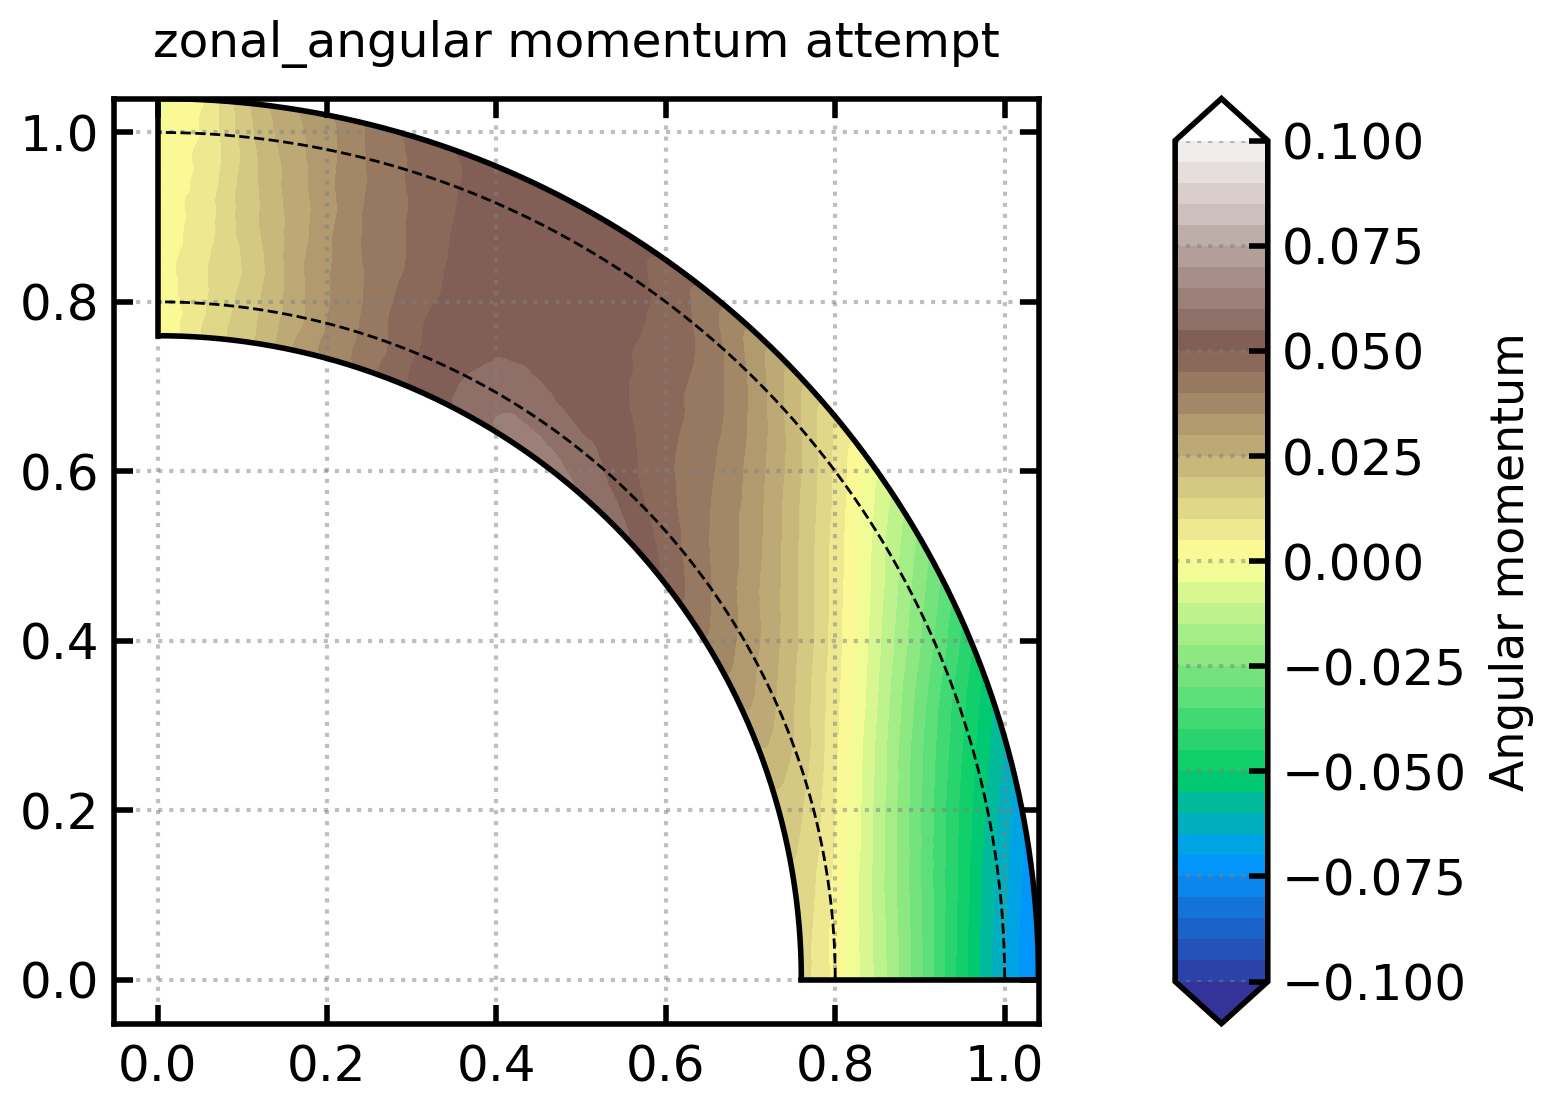

In [5]:
grid1 = gs.GridSpec(1,3, wspace=0.2, hspace=0.18, bottom=0.05, top=0.975, left=0.025, right=0.85, width_ratios=[1,0,0.1])
fig1 = plt.figure(figsize=(7,5))



def e_to_10_fn(s1): 
    return s1.split('e')[0]+r'$\times10^{%s}$'%s1.split('e')[1]


cmap1 = mpl.cm.terrain
levels1 = np.linspace(-0.1, 0.1, 41)
norm1 = mpl.colors.BoundaryNorm(levels1, cmap1.N, extend='both')

smap1 = mpl.cm.ScalarMappable(cmap=cmap1, norm=norm1)


sintheta1 = np.sin(theta1)
costheta1 = np.cos(theta1)
x1 = sintheta1 * r1/5 
y1 = costheta1 * r1/5
        
ax1 = fig1.add_subplot(grid1[0])  
ax1.set_title("zonal_angular momentum attempt")      
#ax1.set_xlim([-.005,1.1])
#ax1.set_ylim([-.005,1.1])
ax1.set_aspect('equal', adjustable='box')        
ax1.plot(x1[:,0], y1[:,0],'k', lw=2)
ax1.plot(x1[:,-1], y1[:,-1],'k', lw=2)
ax1.plot(x1[:,-1]*5/5.2, y1[:,-1]*5/5.2,'k', lw=1, ls='--')
ax1.plot(x1[:,-1]*4/5.2, y1[:,-1]*4/5.2,'k', lw=1, ls='--')
ax1.plot([0,0],[y1[-1,0],y1[-1,-1]], 'k', lw=2)
ax1.plot([3.8/5,5.2/5],[0,0], 'k', lw=2)
#ax1.text(0.,0.14,r'Ra$_{\text{F}}$ = '+e_to_10_fn('3e8'), ha='left', fontsize=20)#, pad=-50)
#ax1.text(0.,0.02,r'Ta   \ \ \kern1pt= '+e_to_10_fn('1e5'), ha='left', fontsize=20)#, pad=-50)
#ax1.axis('off')
ax1.contourf(x1, y1, u1, levels=levels1, cmap=cmap1, norm=norm1, extend='both')





cgrid1 = gs.GridSpecFromSubplotSpec(8,1, subplot_spec=grid1[0, -1])
cax1 = fig1.add_subplot(cgrid1[:]) 
cbar1=plt.colorbar(smap1, cax=cax1, orientation='vertical')
cbar1.ax.yaxis.minorticks_off()
cbar1.set_label(r'Angular momentum')
plt.savefig('/home/bs583/analysis_notebooks/zonal_velocity_plots/zonal_angular_momentum_attempt.jpg', dpi=1000, bbox_inches='tight')
            

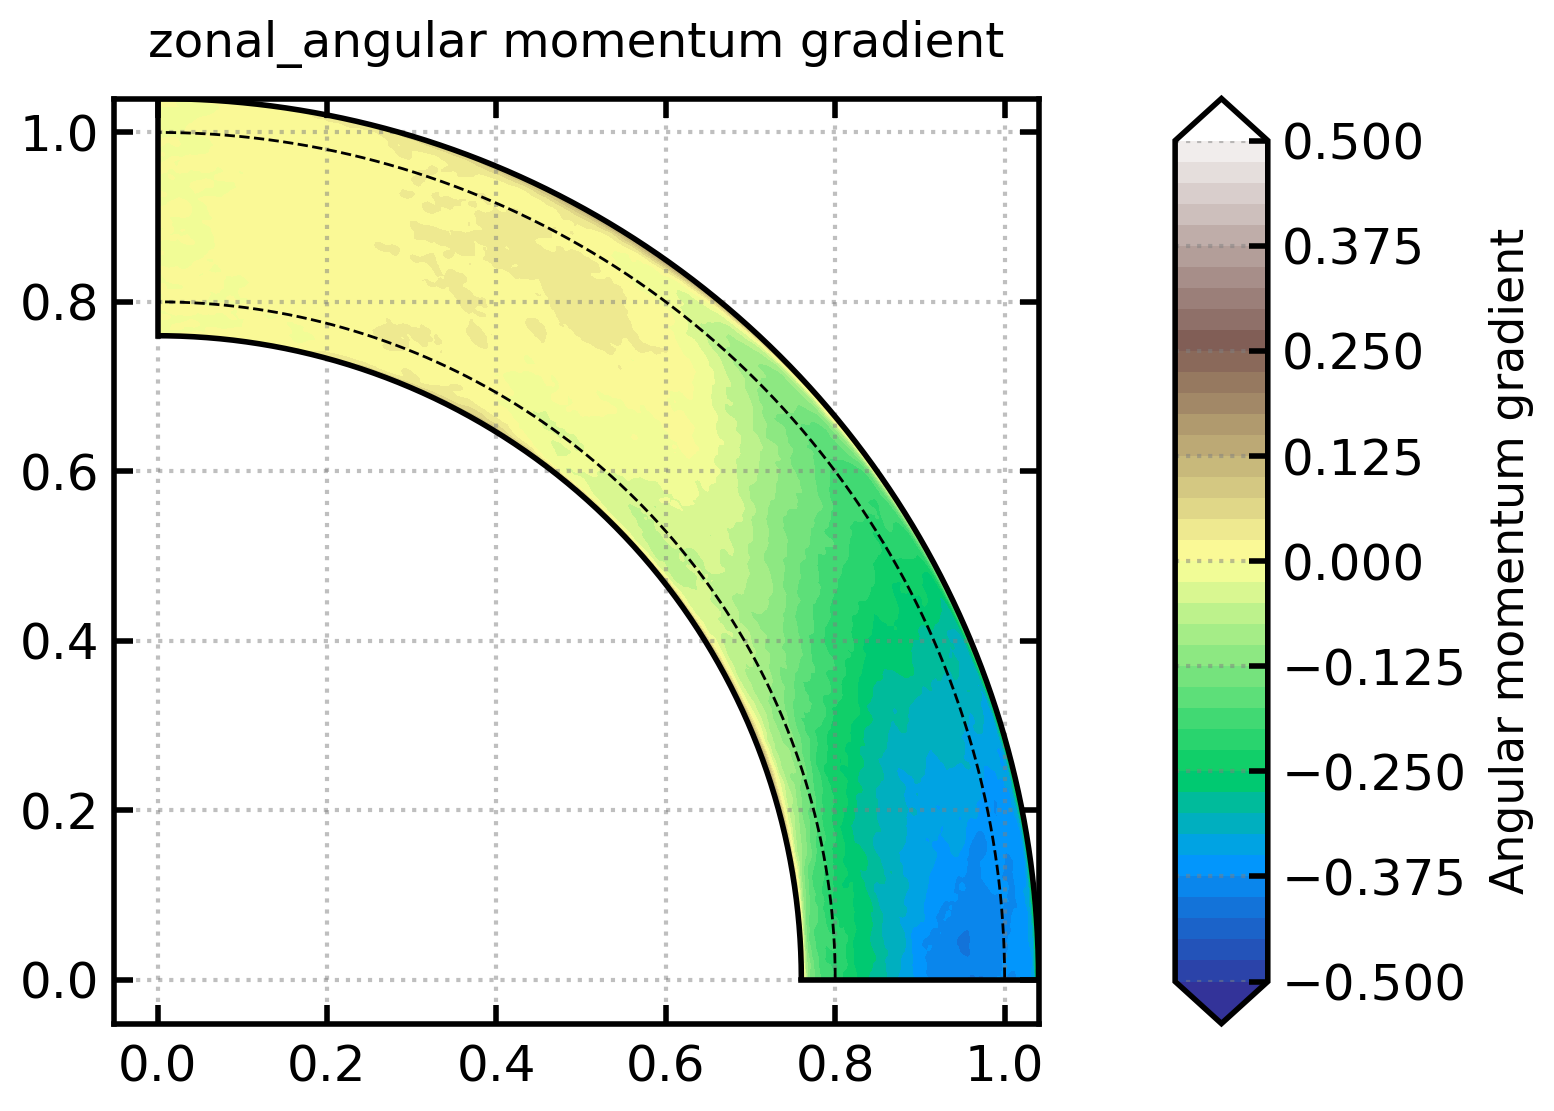

In [6]:
ang_mom_grad = spec_ang_mom.differentiate("r")

grid1 = gs.GridSpec(1,3, wspace=0.2, hspace=0.18, bottom=0.05, top=0.975, left=0.025, right=0.85, width_ratios=[1,0,0.1])
fig1 = plt.figure(figsize=(7,5))



def e_to_10_fn(s1): 
    return s1.split('e')[0]+r'$\times10^{%s}$'%s1.split('e')[1]


cmap1 = mpl.cm.terrain
levels1 = np.linspace(-0.5, 0.5, 41)
norm1 = mpl.colors.BoundaryNorm(levels1, cmap1.N, extend='both')

smap1 = mpl.cm.ScalarMappable(cmap=cmap1, norm=norm1)


sintheta1 = np.sin(theta1)
costheta1 = np.cos(theta1)
x1 = sintheta1 * r1/5 
y1 = costheta1 * r1/5
        
ax1 = fig1.add_subplot(grid1[0])  
ax1.set_title("zonal_angular momentum gradient")      
#ax1.set_xlim([-.005,1.1])
#ax1.set_ylim([-.005,1.1])
ax1.set_aspect('equal', adjustable='box')        
ax1.plot(x1[:,0], y1[:,0],'k', lw=2)
ax1.plot(x1[:,-1], y1[:,-1],'k', lw=2)
ax1.plot(x1[:,-1]*5/5.2, y1[:,-1]*5/5.2,'k', lw=1, ls='--')
ax1.plot(x1[:,-1]*4/5.2, y1[:,-1]*4/5.2,'k', lw=1, ls='--')
ax1.plot([0,0],[y1[-1,0],y1[-1,-1]], 'k', lw=2)
ax1.plot([3.8/5,5.2/5],[0,0], 'k', lw=2)
#ax1.text(0.,0.14,r'Ra$_{\text{F}}$ = '+e_to_10_fn('3e8'), ha='left', fontsize=20)#, pad=-50)
#ax1.text(0.,0.02,r'Ta   \ \ \kern1pt= '+e_to_10_fn('1e5'), ha='left', fontsize=20)#, pad=-50)
#ax1.axis('off')
ax1.contourf(x1, y1, ang_mom_grad, levels=levels1, cmap=cmap1, norm=norm1, extend='both')





cgrid1 = gs.GridSpecFromSubplotSpec(8,1, subplot_spec=grid1[0, -1])
cax1 = fig1.add_subplot(cgrid1[:]) 
cbar1=plt.colorbar(smap1, cax=cax1, orientation='vertical')
cbar1.ax.yaxis.minorticks_off()
cbar1.set_label(r'Angular momentum gradient')
plt.savefig('/home/bs583/analysis_notebooks/zonal_velocity_plots/zonal_angular_momentum_gradient_attempt.jpg', dpi=1000, bbox_inches='tight')
            

<xarray.DataArray 'b_phi_avg' (theta: 384, r: 240)> Size: 737kB
array([[ 1.79357385e-04,  3.26474760e-04,  9.11920943e-04, ...,
         5.22408484e-04,  1.75621291e-04,  9.14042269e-05],
       [ 1.48949429e-04,  2.84496693e-04,  8.44149743e-04, ...,
         5.90755032e-04,  2.26429651e-04,  1.31978760e-04],
       [ 1.65721267e-04,  3.04260278e-04,  8.66159872e-04, ...,
         5.89329638e-04,  2.20166470e-04,  1.25985296e-04],
       ...,
       [ 1.59686995e-03,  2.15467132e-03,  3.57064127e-03, ...,
        -8.81682843e-04, -1.03404821e-03, -8.97907989e-04],
       [ 6.30498559e-04,  9.76852698e-04,  2.16455876e-03, ...,
         2.79202474e-04, -8.31336849e-05, -1.29464039e-04],
       [-2.69691030e-03, -3.15922725e-03, -3.08483632e-03, ...,
         4.71102308e-03,  3.40243998e-03,  2.66651143e-03]],
      shape=(384, 240))
Coordinates:
  * theta    (theta) float64 3kB 1.569 1.565 1.561 ... 0.01126 0.007183 0.003129
  * r        (r) float64 2kB 3.8 3.8 3.8 3.801 3.801 ... 5.19

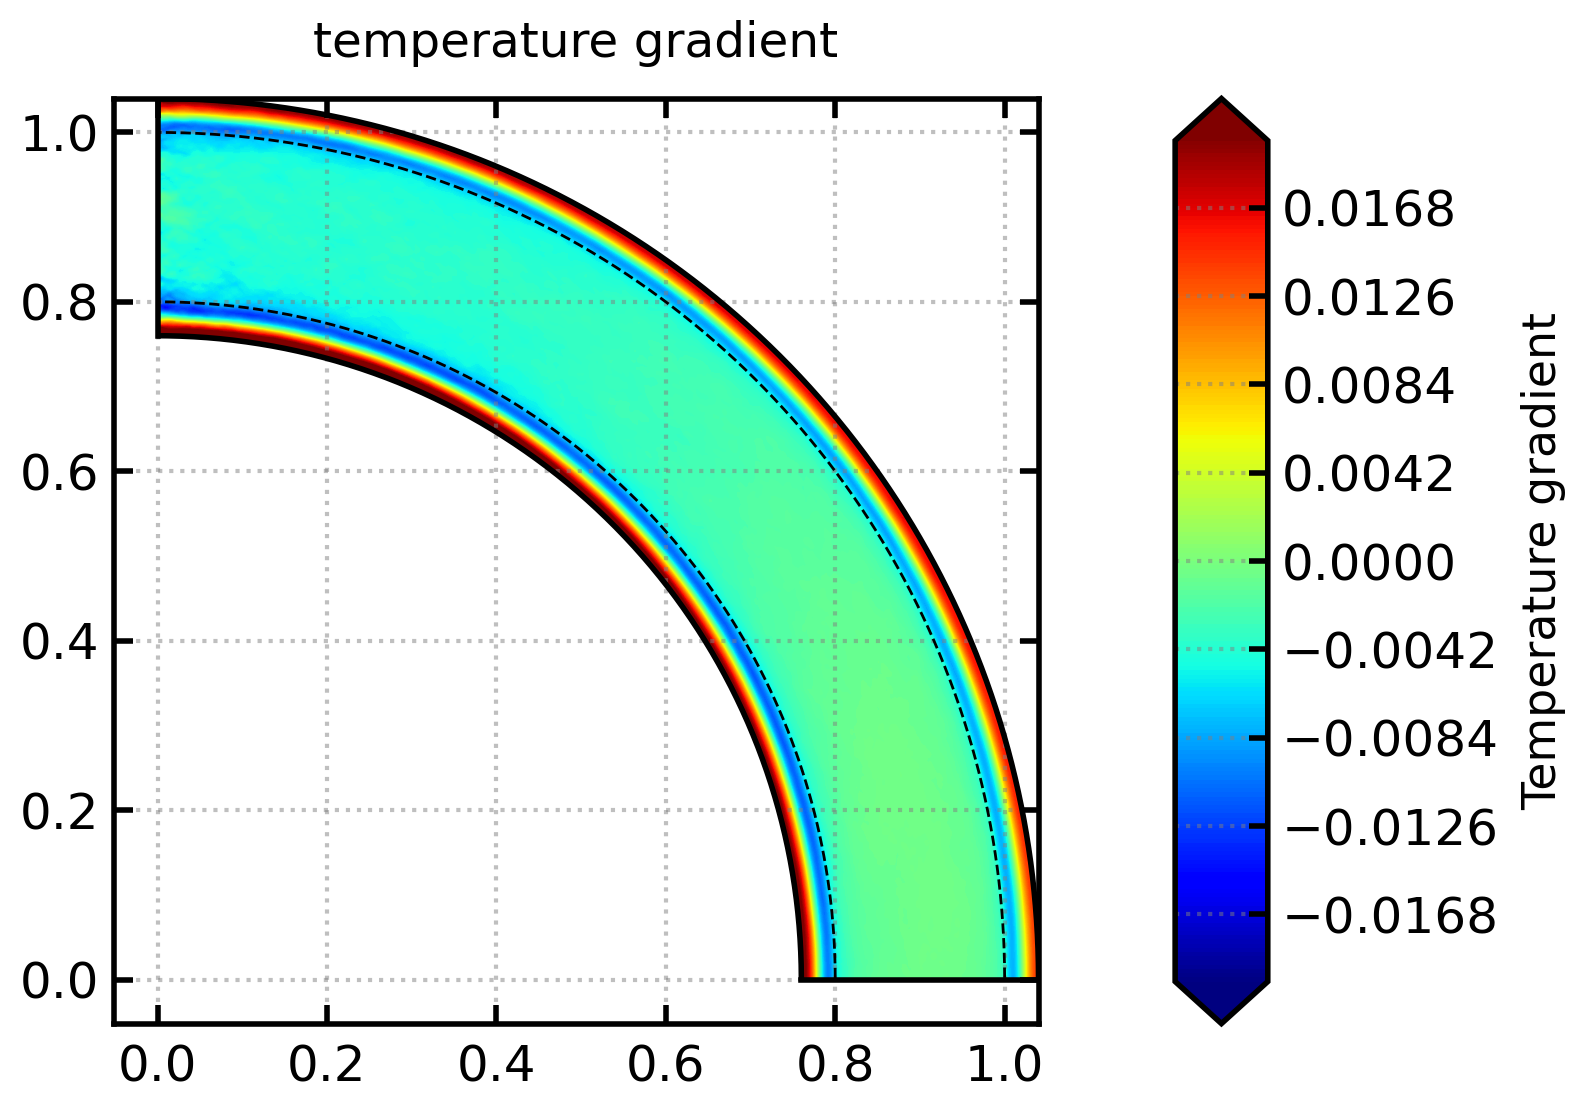

In [7]:
bouyancy = ds.b_phi_avg.sel(theta=slice(np.pi/2,0))
theta_b = bouyancy.theta 
r_b = bouyancy.r 


temp_grad = bouyancy.differentiate("r")
sintheta_b = np.sin(theta_b)
costheta_b = np.cos(theta_b)
x_b = sintheta_b * r1/5 
y_b = costheta_b * r1/5
print(temp_grad)
print(f"temp gradient low {temp_grad.min()}. high {temp_grad.max()}")


grid_b = gs.GridSpec(1,3, wspace=0.2, hspace=0.18, bottom=0.05, top=0.975, left=0.025, right=0.85, width_ratios=[1,0,0.1])
fig_b = plt.figure(figsize=(7,5))



def e_to_10_fn(s1): 
    return s1.split('e')[0]+r'$\times10^{%s}$'%s1.split('e')[1]




cmap_b = mpl.cm.jet
levels_b = np.linspace(-0.02, 0.02, 201)
norm_b = mpl.colors.BoundaryNorm(levels_b, cmap_b.N, extend='both')

smap_b = mpl.cm.ScalarMappable(cmap=cmap_b, norm=norm_b)

ax_b = fig_b.add_subplot(grid_b[0])        
ax_b.set_title("temperature gradient")
#ax_b.set_xlim([-.005,1.1])
#ax_b.set_ylim([-.005,1.1])
ax_b.set_aspect('equal', adjustable='box')        
ax_b.plot(x_b[:,0], y_b[:,0],'k', lw=2)
ax_b.plot(x_b[:,-1], y_b[:,-1],'k', lw=2)
ax_b.plot(x_b[:,-1]*5/5.2, y_b[:,-1]*5/5.2,'k', lw=1, ls='--')
ax_b.plot(x_b[:,-1]*4/5.2, y_b[:,-1]*4/5.2,'k', lw=1, ls='--')
ax_b.plot([0,0],[y1[-1,0],y_b[-1,-1]], 'k', lw=2)
ax_b.plot([3.8/5,5.2/5],[0,0], 'k', lw=2)
#ax_b.text(0.,0.14,r'Ra$_{\text{F}}$ = '+e_to_10_fn('3e8'), ha='left', fontsize=20)#, pad=-50)
#ax_b.text(0.,0.02,r'Ta   \ \ \kern1pt= '+e_to_10_fn('1e5'), ha='left', fontsize=20)#, pad=-50)
#ax_b.axis('off')
ax_b.contourf(x_b, y_b, temp_grad, levels=levels_b, cmap=cmap_b, norm=norm_b, extend='both')





cgrid_b = gs.GridSpecFromSubplotSpec(8,1, subplot_spec=grid_b[0, -1])
cax_b = fig_b.add_subplot(cgrid_b[:]) 
cbar_b=plt.colorbar(smap_b, cax=cax_b, orientation='vertical')
cbar_b.ax.yaxis.minorticks_off()
cbar_b.set_label(r'Temperature gradient')

plt.savefig('/home/bs583/analysis_notebooks/zonal_velocity_plots/temp_gradient.jpg', dpi=1000, bbox_inches='tight')
            

upvp_phi_avg is reynolds stress

In [8]:
upvp = ds.upvp_phi_avg.sel(theta=slice(np.pi/2,0))
theta_upvp = upvp.theta 
r_upvp = upvp.r
print(upvp)


<xarray.DataArray 'upvp_phi_avg' (theta: 384, r: 240)> Size: 737kB
[92160 values with dtype=float64]
Coordinates:
  * theta    (theta) float64 3kB 1.569 1.565 1.561 ... 0.01126 0.007183 0.003129
  * r        (r) float64 2kB 3.8 3.8 3.8 3.801 3.801 ... 5.199 5.199 5.2 5.2 5.2


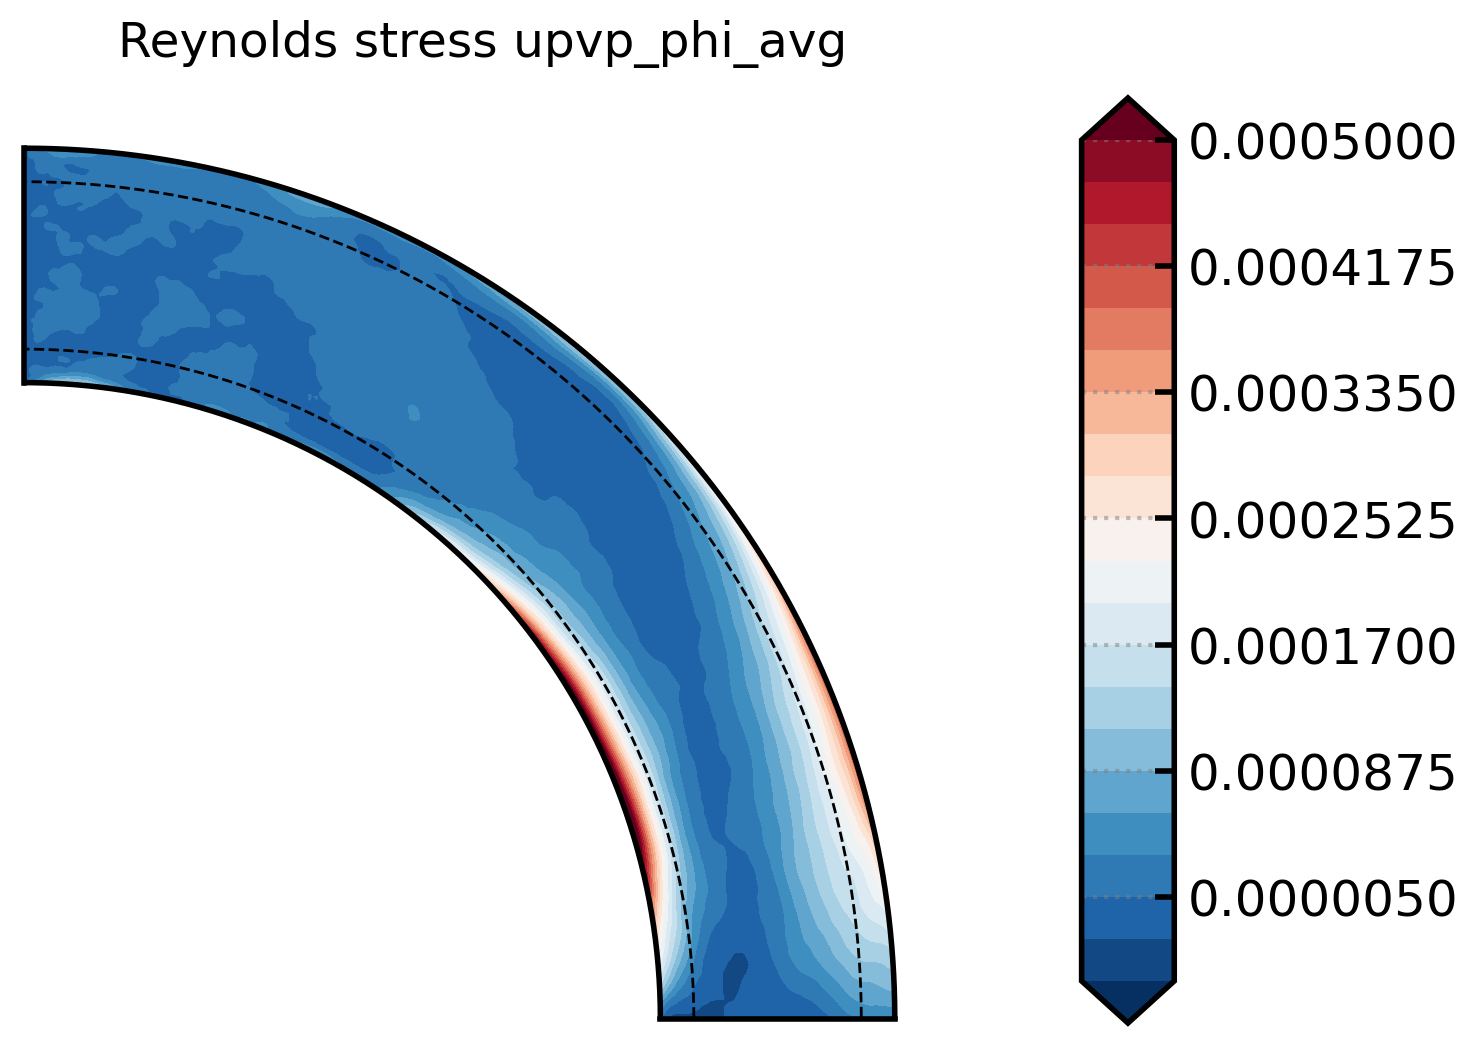

In [9]:
grid = gs.GridSpec(1,3, wspace=0.2, hspace=0.18, bottom=0.05, top=0.975, left=0.025, right=0.85, width_ratios=[1,0,0.1])
fig = plt.figure(figsize=(7,5))



def e_to_10_fn(s1): 
    return s1.split('e')[0]+r'$\times10^{%s}$'%s1.split('e')[1]

cmap = plt.cm.RdBu_r
levels = np.linspace(-0.00005, 0.0005, 21)
norm = mpl.colors.BoundaryNorm(levels, cmap.N, extend='both')

smap = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)


sintheta = np.sin(theta_upvp)
costheta = np.cos(theta_upvp)
x_upvp = sintheta * r_upvp/5 
y_upvp = costheta * r_upvp/5
        
ax_upvp = fig.add_subplot(grid[0])      
ax_upvp.set_title("Reynolds stress upvp_phi_avg")  
ax_upvp.set_xlim([-.005,1.1])
ax_upvp.set_ylim([-.005,1.1])
ax_upvp.set_aspect('equal', adjustable='box')        
ax_upvp.plot(x_upvp[:,0], y_upvp[:,0],'k', lw=2)
ax_upvp.plot(x_upvp[:,-1], y_upvp[:,-1],'k', lw=2)
ax_upvp.plot(x_upvp[:,-1]*5/5.2, y_upvp[:,-1]*5/5.2,'k', lw=1, ls='--')
ax_upvp.plot(x_upvp[:,-1]*4/5.2, y_upvp[:,-1]*4/5.2,'k', lw=1, ls='--')
ax_upvp.plot([0,0],[y_upvp[-1,0],y_upvp[-1,-1]], 'k', lw=2)
ax_upvp.plot([3.8/5,5.2/5],[0,0], 'k', lw=2)
#ax_upvp.text(0.,0.14,r'Ra$_{\text{F}}$ = '+e_to_10_fn('3e8'), ha='left', fontsize=20)#, pad=-50)
#ax_upvp.text(0.,0.02,r'Ta   \ \ \kern1pt= '+e_to_10_fn('1e5'), ha='left', fontsize=20)#, pad=-50)
ax_upvp.axis('off')
ax_upvp.contourf(x_upvp, y_upvp, upvp, levels=levels, cmap=cmap, norm=norm, extend='both')





cgrid = gs.GridSpecFromSubplotSpec(8,1, subplot_spec=grid[0, -1])
cax = fig.add_subplot(cgrid[:]) 
cbar=plt.colorbar(smap, cax=cax, orientation='vertical')
cbar.ax.yaxis.minorticks_off()
#cbar.set_label(r'$U$')

plt.savefig('/home/bs583/analysis_notebooks/zonal_velocity_plots/Reynolds_stress_upvp_phi_avg.jpg', dpi=1000, bbox_inches='tight')
            

In [10]:
grid = gs.GridSpec(1,3, wspace=0.2, hspace=0.18, bottom=0.05, top=0.975, left=0.025, right=0.85, width_ratios=[1,0,0.1])
fig = plt.figure(figsize=(7,5))



def e_to_10_fn(s1): 
    return s1.split('e')[0]+r'$\times10^{%s}$'%s1.split('e')[1]

cmap = plt.cm.RdBu_r
levels = np.linspace(0, .01, 21)
norm = mpl.colors.BoundaryNorm(levels, cmap.N, extend='both')

smap = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)


sintheta = np.sin(theta)
costheta = np.cos(theta)
x = sintheta * r/5 
y = costheta * r/5
        
ax = fig.add_subplot(grid[0])      
ax.set_title("reynolds stress")  
ax.set_xlim([-.005,1.1])
ax.set_ylim([-.005,1.1])
ax.set_aspect('equal', adjustable='box')        
ax.plot(x[:,0], y[:,0],'k', lw=2)
ax.plot(x[:,-1], y[:,-1],'k', lw=2)
ax.plot(x[:,-1]*5/5.2, y[:,-1]*5/5.2,'k', lw=1, ls='--')
ax.plot(x[:,-1]*4/5.2, y[:,-1]*4/5.2,'k', lw=1, ls='--')
ax.plot([0,0],[y[-1,0],y[-1,-1]], 'k', lw=2)
ax.plot([3.8/5,5.2/5],[0,0], 'k', lw=2)
#ax.text(0.,0.14,r'Ra$_{\text{F}}$ = '+e_to_10_fn('3e8'), ha='left', fontsize=20)#, pad=-50)
#ax.text(0.,0.02,r'Ta   \ \ \kern1pt= '+e_to_10_fn('1e5'), ha='left', fontsize=20)#, pad=-50)
ax.axis('off')
ax.contourf(x, y, r_stress, levels=levels, cmap=cmap, norm=norm, extend='both')





cgrid = gs.GridSpecFromSubplotSpec(8,1, subplot_spec=grid[0, -1])
cax = fig.add_subplot(cgrid[:]) 
cbar=plt.colorbar(smap, cax=cax, orientation='vertical')
cbar.ax.yaxis.minorticks_off()
#cbar.set_label(r'$U$')

plt.savefig('/home/bs583/analysis_notebooks/zonal_velocity_plots/Reynolds_stress.jpg', dpi=1000, bbox_inches='tight')
            

NameError: name 'theta' is not defined

<Figure size 700x500 with 0 Axes>